In [2]:

#subject definitions for tumor cohort
subj_list = ["np93","np95","np101","np102","np114","np128","np129","np132","np136","np137","np138","np139","np171","np174",
"np78","np80","np91","np96","np110","127","np158","np169","np172","np173"]
preop_scores = [10, 9.7, 9.79, 10, 9.058, 9.469, 9.823, 9.382, 9.788, 9.775, 9.895, 10, 9.925, 9.724,
9.785, 10, 9.874, 9.549, 10, 10, 10, 8.791, 9.683, 8.825]
age_list = [28, 28, 54, 24, 59, 34, 39, 43, 63, 38, 43, 29, 79, 55,
23, 57, 38, 22, 61, 39, 63, 64, 61, 64]
sex_list = [1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
grade_list = [4, 4, 4, 2, 4, 2, 4, 2, 4, 2, 2, 2, 4, 4,
2, 2, 3, 2, 2, 2, 4, 4, 4, 4]
idh_wt = [0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 
0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
insular_list = [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
1, 1, 0, 0, 1, 1, 0, 0, 0, 0]
volume_list = [6.6, 5.2, 7.7, 49.9, 12.7, 89.1, 271.2, 95.0, 3.5, 94.8, 21.0, 16.0, 0.7, 3.8,
33.4, 45.4, 160.0, 10.1, 23.7, 37.4, 5.4, 9.6, 1.7, 33.9]
np_list = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

print(len(subj_list))
print(len(preop_scores))
print(len(age_list))
print(len(sex_list))
print(len(grade_list))
print(len(idh_wt))
print(len(insular_list))
print(len(volume_list))
print(len(np_list))

24
24
24
24
24
24
24
24
24


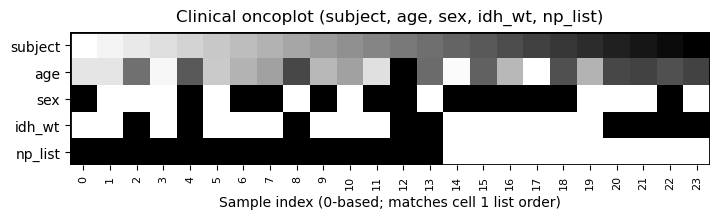

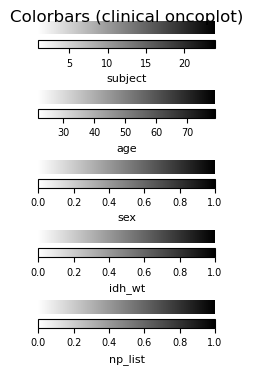

In [3]:
# Oncoplot-style stacked heatmap (clinical / cohort annotations)
# Requires cell 1: subj_list, age_list, sex_list, idh_wt (aligned insertions)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

plt.rcParams['svg.fonttype'] = 'none'

n = len(subj_list)
if not (len(age_list) == n and len(sex_list) == n and len(idh_wt) == n and len(np_list) == n):
    raise ValueError('age_list, sex_list, idh_wt, np_list must match len(subj_list)')

# Columns = samples 1 .. n (same order as vectors in cell 1)
subject_row = list(range(1, n + 1))

# Note: volume_list is now omitted completely

all_lists = [
    subject_row,
    age_list,
    sex_list,
    idh_wt,
    np_list,
]
list_names = [
    'subject',
    'age',
    'sex',
    'idh_wt',
    'np_list',
]

matrix = []
row_vmin = []
row_vmax = []
for idx, lst in enumerate(all_lists):
    name = list_names[idx]
    # Treat idh_wt, np_list as continuous/numeric, rest handled identically here
    arr = np.asarray(lst, dtype=float)
    matrix.append(arr.tolist())
    finite = arr[np.isfinite(arr)]
    if finite.size:
        row_vmin.append(float(np.min(finite)))
        row_vmax.append(float(np.max(finite)))
    else:
        row_vmin.append(0.0)
        row_vmax.append(1.0)

matrix = np.array(matrix, dtype=float)

wb_cmap = LinearSegmentedColormap.from_list('wb', ['white', 'black'])

n_rows, n_cols = matrix.shape
aspect_ratio = 1
base = 8
figsize = (base * aspect_ratio, base) if n_cols >= n_rows else (base, base * aspect_ratio)

fig, ax = plt.subplots(figsize=figsize)

for i in range(n_rows):
    row = np.ma.masked_invalid(np.asarray(matrix[i], dtype=float))[np.newaxis, :]
    ax.imshow(
        row,
        aspect='auto',
        cmap=wb_cmap,
        vmin=row_vmin[i],
        vmax=row_vmax[i],
        extent=[-0.5, n_cols - 0.5, i + 0.5, i - 0.5],
    )

# (Removed: annotate volume row with volume + IDH_wt, since volume removed)

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(list_names, fontsize=10)
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels([str(i) for i in range(n_cols)], rotation=90, fontsize=8)
ax.set_xlabel('Sample index (0-based; matches cell 1 list order)')

for spine in ax.spines.values():
    spine.set_visible(False)

rect = mpatches.Rectangle((-0.5, -0.5), n_cols, n_rows, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(rect)

ax.set_ylim(n_rows - 0.5, -0.5)
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_aspect(aspect_ratio, adjustable='box')

plt.subplots_adjust(left=0.18, right=0.98, top=0.92, bottom=0.15)
plt.title('Clinical oncoplot (subject, age, sex, idh_wt, np_list)', y=1.02)
plt.savefig('oncoplot_clinical_summary.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# Optional: colorbars per row
from matplotlib import gridspec

fig_cb, axes_cb = plt.subplots(nrows=n_rows, ncols=1, figsize=(2, n_rows * 0.7), constrained_layout=True)
if n_rows == 1:
    axes_cb = [axes_cb]

for i in range(n_rows):
    dummy = np.linspace(row_vmin[i], row_vmax[i], 256).reshape(1, -1)
    im = axes_cb[i].imshow(dummy, aspect='auto', cmap=wb_cmap, vmin=row_vmin[i], vmax=row_vmax[i])
    cbar = plt.colorbar(im, ax=axes_cb[i], orientation='horizontal', fraction=0.7, pad=0.2)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label(list_names[i], fontsize=8)
    axes_cb[i].axis('off')

fig_cb.suptitle('Colorbars (clinical oncoplot)', fontsize=12, y=1.02)
plt.savefig('oncoplot_clinical_colorbars.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


All Subjects — One-sided t-test (idh_wt 1 < idh_wt 0): t=-1.825, p=0.0492
All Subjects — One-sided Mann-Whitney U test (idh_wt 1 < idh_wt 0): U=40.000, p=0.0516
First 14 — One-sided t-test (idh_wt 1 < idh_wt 0): t=-0.733, p=0.245


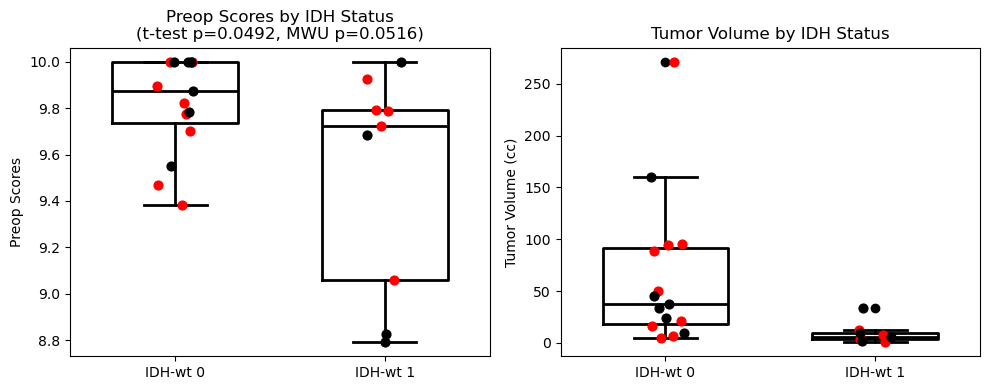

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np
import pandas as pd

# Compat shim: numpy 2.x removed np.matrix; older matplotlib still references it
# during figure rendering (isinstance(a, np.matrix)), which triggers AttributeError
# on savefig / show. Aliasing it to a dummy class makes the isinstance check a no-op.
if not hasattr(np, 'matrix'):
    np.matrix = type('matrix', (), {})

plt.rcParams['svg.fonttype'] = 'none'

df_compare = pd.DataFrame({
    "preop": preop_scores,
    "idh_wt": idh_wt,
    "volume": volume_list
})

preop_idh0  = np.asarray(df_compare[df_compare["idh_wt"] == 0]["preop"]).ravel()
preop_idh1  = np.asarray(df_compare[df_compare["idh_wt"] == 1]["preop"]).ravel()
volume_idh0 = np.asarray(df_compare[df_compare["idh_wt"] == 0]["volume"]).ravel()
volume_idh1 = np.asarray(df_compare[df_compare["idh_wt"] == 1]["volume"]).ravel()

# One-sided t-test (all subjects): H0: mean1 >= mean0, H1: mean1 < mean0
t_stat, p_ttest = ttest_ind(preop_idh1, preop_idh0, equal_var=False, alternative='less')
u_stat, p_mwu   = mannwhitneyu(preop_idh1, preop_idh0, alternative='less')

print("All Subjects — One-sided t-test (idh_wt 1 < idh_wt 0): t=%.3f, p=%.3g" % (t_stat, p_ttest))
print("All Subjects — One-sided Mann-Whitney U test (idh_wt 1 < idh_wt 0): U=%.3f, p=%.3g" % (u_stat, p_mwu))

# Subset: first 14 data points only
preop_scores_14 = preop_scores[:14]
idh_wt_14       = idh_wt[:14]
volume_14       = volume_list[:14]
df_compare_14   = pd.DataFrame({"preop": preop_scores_14, "idh_wt": idh_wt_14, "volume": volume_14})
preop_idh0_14   = np.asarray(df_compare_14[df_compare_14["idh_wt"] == 0]["preop"]).ravel()
preop_idh1_14   = np.asarray(df_compare_14[df_compare_14["idh_wt"] == 1]["preop"]).ravel()
volume_idh0_14  = np.asarray(df_compare_14[df_compare_14["idh_wt"] == 0]["volume"]).ravel()
volume_idh1_14  = np.asarray(df_compare_14[df_compare_14["idh_wt"] == 1]["volume"]).ravel()

if len(preop_idh1_14) > 0 and len(preop_idh0_14) > 0:
    t_stat_14, p_ttest_14 = ttest_ind(preop_idh1_14, preop_idh0_14, equal_var=False, alternative='less')
    print("First 14 — One-sided t-test (idh_wt 1 < idh_wt 0): t=%.3f, p=%.3g" % (t_stat_14, p_ttest_14))
else:
    print("First 14 — Not enough data for t-test.")

# --- BOXPLOTS WITH INDIVIDUAL DATA POINTS OVERLAID ---
fig, axarr = plt.subplots(1, 2, figsize=(10, 4))

def get_point_colors(ids, first_n=14, color_first='red', color_rest='black'):
    return [color_first if idx < first_n else color_rest for idx in ids]

# Preop Scores by IDH status
ax = axarr[0]
ax.boxplot(
    [preop_idh0, preop_idh1],
    patch_artist=False,
    positions=[1, 2],
    widths=0.6,
    boxprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=6, linewidth=2)
)
ax.set_ylabel('Preop Scores')
ax.set_title('Preop Scores by IDH Status\n(t-test p=%.3g, MWU p=%.3g)' % (p_ttest, p_mwu))
ax.set_xticks([1, 2])
ax.set_xticklabels(["IDH-wt 0", "IDH-wt 1"])

for idh_status, x_pos in zip([0, 1], [1, 2]):
    idxs = [i for i, v in enumerate(idh_wt) if v == idh_status]
    group_scores = [preop_scores[i] for i in idxs]
    for score, idx in zip(group_scores, idxs):
        c = 'red' if idx < 14 else 'black'
        ax.scatter(x_pos + np.random.uniform(-0.09, 0.09), score, color=c, s=40, zorder=3)

# Tumor Volume by IDH status
ax = axarr[1]
ax.boxplot(
    [volume_idh0, volume_idh1],
    patch_artist=False,
    positions=[1, 2],
    widths=0.6,
    boxprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=6, linewidth=2)
)
ax.set_ylabel('Tumor Volume (cc)')
ax.set_title('Tumor Volume by IDH Status')
ax.set_xticks([1, 2])
ax.set_xticklabels(["IDH-wt 0", "IDH-wt 1"])

for idh_status, x_pos in zip([0, 1], [1, 2]):
    idxs = [i for i, v in enumerate(idh_wt) if v == idh_status]
    group_volumes = [volume_list[i] for i in idxs]
    for volume, idx in zip(group_volumes, idxs):
        c = 'red' if idx < 14 else 'black'
        ax.scatter(x_pos + np.random.uniform(-0.09, 0.09), volume, color=c, s=40, zorder=3)

fig.tight_layout()
fig.savefig("preopbehavior.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# =====================================================================
# MULTIPLE LINEAR REGRESSION: chosen outcome ~ chosen predictors
#
# INCLUDE: comma-separated predictors. Any subset of:
#   age       (continuous)
#   grade     (categorical: 2 vs 4)
#   idh_wt    (categorical: 0 vs 1)
#   insular   (categorical: 0 vs 1)
#   volume    (continuous)
#
# OUTCOME: which version of preop_scores to regress on.
#   "raw"        -> preop_scores exactly as entered (bounded at 10)
#   "invnorm"    -> inverse-normal (Van der Waerden) rank transform. Best for
#                   parametric OLS when the raw outcome is ceilinged.
#   "percentile" -> 0-100 empirical percentile (uniform distribution)
#   "rank"       -> 1..n raw rank (uniform, integer)
# =====================================================================
INCLUDE = "idh_wt, volume"
OUTCOME = "raw"

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as sp_stats

_preop_series = pd.Series(preop_scores)
_n = len(_preop_series)
_preop_pct     = (_preop_series.rank(method="average", pct=True) * 100).values
_preop_rank    = _preop_series.rank(method="average").values
_preop_invnorm = sp_stats.norm.ppf((_preop_series.rank(method="average") - 0.5) / _n)

OUTCOME_MAP = {
    "raw":        ("preop",      np.asarray(preop_scores, dtype=float)),
    "invnorm":    ("preop_inv",  _preop_invnorm),
    "percentile": ("preop_pct",  _preop_pct),
    "rank":       ("preop_rank", _preop_rank),
}
if OUTCOME not in OUTCOME_MAP:
    raise ValueError(f"OUTCOME must be one of {list(OUTCOME_MAP)}; got {OUTCOME!r}")
Y_COL, y_values = OUTCOME_MAP[OUTCOME]

df = pd.DataFrame({
    "subj":     subj_list,
    "preop":    preop_scores,
    Y_COL:      y_values,
    "age":      age_list,
    "grade":    grade_list,
    "idh_wt":   idh_wt,
    "insular":  insular_list,
    "volume":   volume_list,
})

VAR_SPEC = {
    "age":     {"kind": "continuous"},
    "grade":   {"kind": "categorical"},
    "idh_wt":  {"kind": "categorical"},
    "insular": {"kind": "categorical"},
    "volume":  {"kind": "continuous"},
}

requested = [v.strip() for v in INCLUDE.split(",") if v.strip()]
unknown = [v for v in requested if v not in VAR_SPEC]
if unknown:
    raise ValueError(f"Unknown variable(s) in INCLUDE: {unknown}. Allowed: {list(VAR_SPEC)}")
if not requested:
    raise ValueError("INCLUDE is empty \u2014 specify at least one predictor.")

rhs_terms = [
    (f"C({v})" if VAR_SPEC[v]["kind"] == "categorical" else v)
    for v in requested
]
formula = f"{Y_COL} ~ " + " + ".join(rhs_terms)
print(f"Outcome: {OUTCOME}  (column '{Y_COL}')")
print(f"Formula: {formula}")
print(f"N subjects: {len(df)}")
print(f"Predictors: {requested}\n")

model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

design = model.model.exog
design_names = model.model.exog_names
if design.shape[1] > 1:
    vif_rows = []
    for j, name in enumerate(design_names):
        if name == "Intercept":
            continue
        try:
            vif = variance_inflation_factor(design, j)
        except Exception:
            vif = np.nan
        vif_rows.append((name, vif))
    vif_df = pd.DataFrame(vif_rows, columns=["term", "VIF"])
    print("\nVariance Inflation Factors (VIF > ~5 = concerning, > 10 = serious collinearity):")
    print(vif_df.to_string(index=False))

print(
    f"\nR\u00b2 = {model.rsquared:.3f} | adj R\u00b2 = {model.rsquared_adj:.3f} | "
    f"F = {model.fvalue:.2f} | p(F) = {model.f_pvalue:.4g} | AIC = {model.aic:.2f} | BIC = {model.bic:.2f}"
)
if OUTCOME != "raw":
    print(
        f"\nNote: OUTCOME='{OUTCOME}'. Coefficients are in units of the transformed scale, not raw preop points.\n"
        f"  Compare p-values to the 'raw' run. If p drops noticeably under 'invnorm', the ceiling in preop_scores\n"
        f"  was suppressing the effect in the raw model."
    )


Outcome: raw  (column 'preop')
Formula: preop ~ C(idh_wt) + volume
N subjects: 24
Predictors: ['idh_wt', 'volume']

                            OLS Regression Results                            
Dep. Variable:                  preop   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     2.585
Date:                Mon, 20 Apr 2026   Prob (F-statistic):             0.0991
Time:                        13:32:02   Log-Likelihood:                -6.3591
No. Observations:                  24   AIC:                             18.72
Df Residuals:                      21   BIC:                             22.25
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------